# Arbitrary Lindblad evolution with `nuDICE`

This notebook demonstrates how to use the generalized `nudice.functions` API to solve a Lindblad master equation for neutrino oscillations without assuming a visible-neutrino-decay model.

For each energy bin, the package evolves a density matrix in the mass basis according to

$$
\frac{d\rho_E}{dL} = -i[H_E, \rho_E] + \sum_a \left(L_{a,E}\rho_E L_{a,E}^\dagger - \frac{1}{2}\{L_{a,E}^\dagger L_{a,E}, \rho_E\}\right),
$$

where `H_E` may be the default vacuum Hamiltonian or a user-supplied Hamiltonian, and the Lindblad operators may be shared across energy bins or energy-dependent.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from nudice.functions import (
    MeV,
    km,
    Uall,
    dagger,
    dynam,
    lind,
    kraus,
    mass_to_flav,
    calc_bin_centres,
)

## 1. Choose energy bins, masses, and a mixing matrix

The solver works internally in eV and eV$^{-1}$.  Here the energy grid is specified in MeV and converted by multiplying by `MeV`; the baseline is specified in km and converted by multiplying by `km`.

In [3]:
# Energy-bin edges and centers.
e_edges = np.linspace(0.5, 5.0, 61) * MeV
e_centers = calc_bin_centres(e_edges)
n_bins = len(e_centers)

# Simple three-neutrino normal-ordering-like mass spectrum in eV.
m1 = 0.0
m2 = np.sqrt(7.42e-5)
m3 = np.sqrt(2.517e-3)
masses = np.array([m1, m2, m3])
Ndim = len(masses)

# Representative mixing angles in radians and CP phase.
theta12 = np.deg2rad(33.44)
theta23 = np.deg2rad(49.2)
theta13 = np.deg2rad(8.57)
deltaCP = np.deg2rad(195.0)
U = Uall(theta12, theta23, theta13, deltaCP)

baseline = 295.0 * km

## 2. Build an initial flavor state

`lind`, `dynam`, and `kraus` expect one density matrix per energy bin in the mass basis.  To start with a pure flavor state $|\nu_\mu\rangle$, build the flavor-basis projector and rotate it to the mass basis.

In [4]:
# Pure nu_mu state in flavor basis.
nu_mu = np.array([0.0, 1.0, 0.0], dtype=complex)
rho_flav_0 = np.outer(nu_mu, nu_mu.conj())

# Convert to mass basis: rho_m = U^dagger rho_f U.
rho_mass_0_single = dagger(U) @ rho_flav_0 @ U

# Use the same initial flavor composition for every energy bin.
rho0 = np.broadcast_to(rho_mass_0_single, (n_bins, Ndim, Ndim)).copy()

## 3. Define arbitrary Lindblad operators

The generalized API accepts any Lindblad operators in the mass basis.  Below are two illustrative operators:

1. A diagonal dephasing operator, which suppresses coherences between mass eigenstates.
2. A relaxation-like jump operator from mass state 3 to mass state 1.

These are not meant to be a specific phenomenological model; they are placeholders showing the expected shape and API.

In [5]:
# Operator 1: diagonal dephasing in the mass basis.
gamma_dephase = 2.0e-23
L_dephase = np.sqrt(gamma_dephase) * np.diag([0.0, 1.0, -1.0])

# Operator 2: an arbitrary jump from |nu_3> to |nu_1>.
gamma_jump = 5.0e-24
L_jump = np.zeros((Ndim, Ndim), dtype=complex)
L_jump[0, 2] = np.sqrt(gamma_jump)

# Shape: (N_ops, Ndim, Ndim). These operators are shared by all energy bins.
operators = np.stack([L_dephase, L_jump])
operators.shape

(2, 3, 3)

## 4. Evolve with the dynamical-map solver

`dynam` exponentiates the Liouvillian and applies the resulting map to the vectorized density matrices.  It is typically convenient when the energy grid is not too large.

In [6]:
rho_mass_L = dynam(
    initial_value=rho0,
    L=baseline,
    e_edges=e_edges,
    masses=masses,
    operators=operators,
)

# Convert every final mass-basis density matrix back to flavor basis.
rho_flav_L = np.array([mass_to_flav(rho, U) for rho in rho_mass_L])
prob_flav = np.real(np.diagonal(rho_flav_L, axis1=1, axis2=2))
prob_flav[:3]

array([[0.38884165, 0.28376015, 0.3273982 ],
       [0.37570046, 0.0650988 , 0.55920074],
       [0.09278027, 0.29812426, 0.60909547]])

## 5. Plot the flavor probabilities

The diagonal entries of the final flavor-basis density matrix are the flavor probabilities for each energy bin.

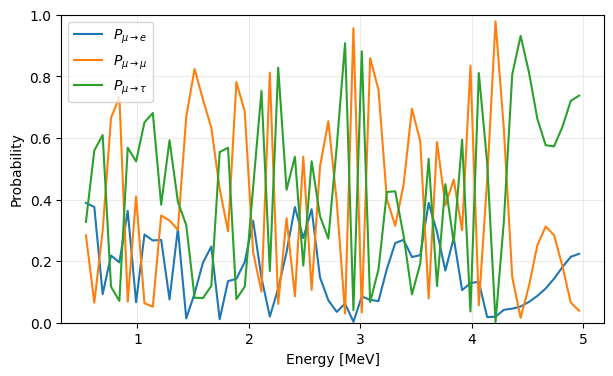

In [7]:
labels = [r"$P_{\mu\to e}$", r"$P_{\mu\to\mu}$", r"$P_{\mu\to\tau}$"]

fig, ax = plt.subplots(figsize=(7, 4))
for i, label in enumerate(labels):
    ax.plot(e_centers / MeV, prob_flav[:, i], label=label)

ax.set_xlabel("Energy [MeV]")
ax.set_ylabel("Probability")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.25)
plt.show()

## 6. Optional: energy-dependent Lindblad operators

For arbitrary models, the operator can be energy-dependent.  Pass a callable with signature

```python
operators(E, bin_index, Ndim) -> array_like
```

where the return value may be a single `(Ndim, Ndim)` matrix or a stack `(N_ops, Ndim, Ndim)` for that energy bin.

In [8]:
def energy_dependent_operators(E, bin_index, Ndim):
    # Example rate scaling; replace with your own model.
    gamma_E = gamma_dephase * (E / (1.0 * MeV))
    op = np.sqrt(gamma_E) * np.diag([0.0, 1.0, -1.0])
    return op

rho_mass_L_energy_dep = dynam(
    initial_value=rho0,
    L=baseline,
    e_edges=e_edges,
    masses=masses,
    operators=energy_dependent_operators,
)

rho_flav_L_energy_dep = np.array([mass_to_flav(rho, U) for rho in rho_mass_L_energy_dep])
prob_flav_energy_dep = np.real(np.diagonal(rho_flav_L_energy_dep, axis1=1, axis2=2))

## 7. Optional: compare solver backends on a smaller grid

The ODE solver (`lind`) and Kraus decomposition (`kraus`) should agree with the dynamical-map solver for the same Hamiltonian and Lindblad operators.  This comparison is kept small because `lind` is generally slower.

In [9]:
small_edges = np.linspace(0.5, 5.0, 9) * MeV
small_centers = calc_bin_centres(small_edges)
small_rho0 = np.broadcast_to(rho_mass_0_single, (len(small_centers), Ndim, Ndim)).copy()

rho_dyn = dynam(small_rho0, baseline, small_edges, masses, operators=operators)
rho_ode = lind(small_rho0, baseline, small_edges, masses, operators=operators, n_steps=80)
rho_kraus = kraus(small_rho0, baseline, small_edges, masses, operators=operators)

print("max |dynam - lind| :", np.max(np.abs(rho_dyn - rho_ode)))
print("max |dynam - kraus|:", np.max(np.abs(rho_dyn - rho_kraus)))

max |dynam - lind| : 0.8997602604667703
max |dynam - kraus|: 0.8997600599786545


## 8. Optional: custom Hamiltonian

If you want to include matter effects or another model-specific Hamiltonian, pass either one shared `(Ndim, Ndim)` matrix or a per-bin `(n_bins, Ndim, Ndim)` array through the `hamiltonian=` keyword.  The example below adds a toy flavor-basis matter potential and rotates it into the mass basis for each energy bin.

In [10]:
# Toy matter potential in the flavor basis. Replace V_e with a physical model.
V_e = 1.0e-22
V_flav = np.diag([V_e, 0.0, 0.0])
V_mass = dagger(U) @ V_flav @ U

# Add the same matter term to every bin by passing a shared Hamiltonian term
# plus the vacuum term constructed explicitly here.
H_custom = np.zeros((n_bins, Ndim, Ndim), dtype=complex)
for k, m in enumerate(masses):
    H_custom[:, k, k] = (m**2 - masses[0]**2) / (2 * e_centers)
H_custom += V_mass

rho_mass_L_matter = dynam(
    initial_value=rho0,
    L=baseline,
    e_edges=e_edges,
    masses=masses,
    operators=operators,
    hamiltonian=H_custom,
)

## Takeaways

- Use `operators=None` for ordinary unitary oscillations.
- Use a matrix or stack of matrices for energy-independent decoherence or jumps.
- Use a callable or `(n_bins, N_ops, Ndim, Ndim)` array for energy-dependent Lindblad operators.
- Use `hamiltonian=` for matter effects or other non-vacuum Hamiltonians.